In [1]:
import pandas as pd
import sqlite3
import numpy as np
import time
import os
import requests
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle, Rectangle, Arc
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from nba_api.stats.static import players
from nba_api.stats.endpoints import commonplayerinfo
from nba_api.stats.endpoints import shotchartdetail
from nba_api.stats.static import teams
from scipy.optimize import minimize


First, we need to load the shot location and center location csv.

In [2]:
shot_loc_df = pd.read_csv('shot_loc.csv')
center_loc_df = pd.read_csv('center_loc.csv')

In [3]:
#We will now create a function which will draw the basketball court for our visualizations.
def draw_court(ax=None, color='black', lw=1.5):
    if ax is None:
        ax = plt.gca()

    # Hoop
    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)
    # Backboard
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)
    # Paint
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False)
    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False)
    # Free throw arcs
    top_ft = Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color)
    bottom_ft = Arc((0, 142.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color, linestyle='dashed')
    # Restricted zone
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color)
    # Three point line
    corner_three_l = Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color)
    corner_three_r = Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color)
    # Center court
    center_outer = Arc((0, 422.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color)
    # Half court line
    outer_lines = Rectangle((-250, -47.5), 500, 470, linewidth=lw, color=color, fill=False)

    court_elements = [hoop, backboard, outer_box, inner_box, top_ft, bottom_ft,
                      restricted, corner_three_l, corner_three_r, three_arc,
                      center_outer, outer_lines]

    for element in court_elements:
        ax.add_patch(element)

    ax.set_xlim(-250, 250)
    ax.set_ylim(-47.5, 422.5)
    ax.set_aspect('equal')
    return ax

Having created this function, we can now create a gif showing the change in shot location over time. The colors were chosen to match our presentation's slides.

In [4]:
years = sorted(center_loc_df['YEAR'].unique())
fig, ax = plt.subplots(figsize=(10, 9))
fig.patch.set_facecolor('#1a2e4a')
ax.set_facecolor('#1a2e4a')

dummy = ax.hexbin([], [], gridsize=40, cmap='plasma', norm=LogNorm(vmin=1, vmax=1000))
cbar = fig.colorbar(dummy, ax=ax, label='Relative Shot Density (log scale)', shrink=0.6, aspect=15)
cbar.ax.yaxis.set_tick_params(color='white')
cbar.ax.yaxis.label.set_color('white')
plt.setp(cbar.ax.get_yticklabels(), color='white')

def animate(i):
    ax.clear()
    year = years[i]
    year_data = center_loc_df[center_loc_df['YEAR'] == year]
    
    ax.hexbin(year_data.LOC_X, year_data.LOC_Y, gridsize=120,
              cmap='plasma', norm=LogNorm(), zorder=1)
    draw_court(ax=ax, color='white', lw=1.5)
    ax.set_title(f"Center Shot Density — {year}", fontsize=14, color='white')
    ax.set_facecolor('#1a2e4a')
    ax.tick_params(colors='white')
    ax.spines[:].set_color('white')
    ax.set_xlim(-250, 250)
    ax.set_ylim(-47.5, 422.5)

anim = FuncAnimation(fig, animate, frames=len(years), interval=1000, repeat=True)
anim.save('shot_density_by_year.gif', writer=PillowWriter(fps=1), savefig_kwargs={'facecolor': '#1a2e4a'})
plt.close()

The next visualization we create is the bar graph showing the change in shots taken by centers which were three pointers.

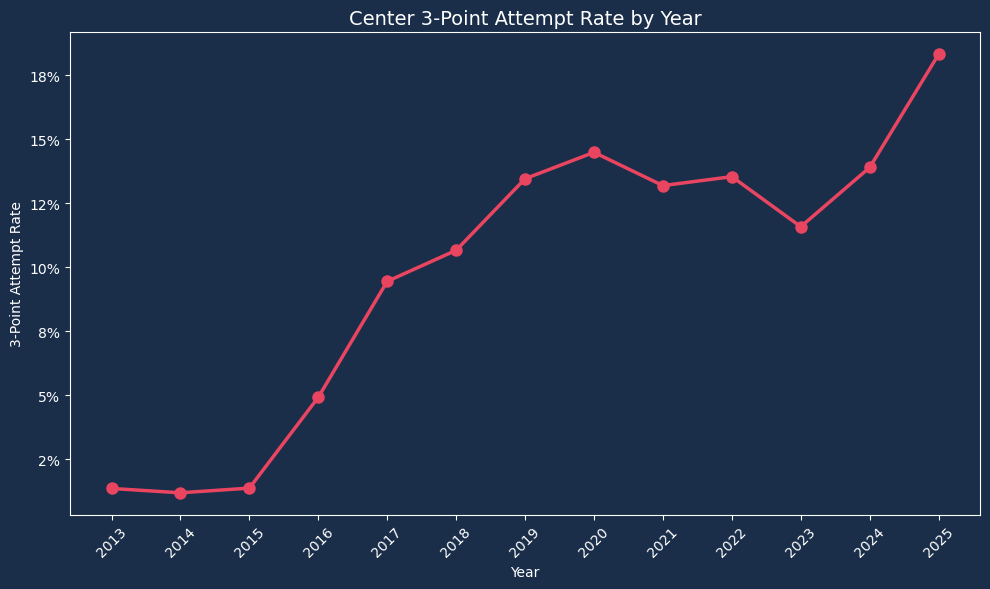

In [5]:
#Turn year into a string so we can group by year where three pointers occur
center_loc_df['YEAR'] = center_loc_df['YEAR'].astype(int)
center_loc_df['IS_THREE'] = (center_loc_df['SHOT_TYPE'] == '3PT Field Goal').astype(int)

center_grouped_df = center_loc_df.groupby('YEAR')['IS_THREE'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#1a2e4a')
ax.set_facecolor('#1a2e4a')

ax.plot(center_grouped_df.index, center_grouped_df.values, color='#e94560', linewidth=2.5, marker='o', markersize=8)

ax.set_title("Center 3-Point Attempt Rate by Year", fontsize=14, color='white')
ax.set_xlabel("Year", color='white')
ax.set_ylabel("3-Point Attempt Rate", color='white')
ax.tick_params(colors='white')
ax.spines[:].set_color('white')

# Format y-axis as percentage
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

ax.set_xticks(center_grouped_df.index)
ax.set_xticklabels(center_grouped_df.index, rotation=45)

plt.tight_layout()
plt.savefig('AttemptRateByYear')
plt.show()

In [6]:
center_loc_df['MADE'] = (center_loc_df['EVENT_TYPE'] == 'Made Shot').astype(int)

# FG% by zone and year
efficiency = center_loc_df.groupby(['YEAR', 'SHOT_ZONE']).agg(
    FGA=('MADE', 'count'),
    FGM=('MADE', 'sum')
).reset_index()

efficiency['FG_PCT'] = efficiency['FGM'] / efficiency['FGA']

efficiency_table = efficiency.pivot(index='YEAR', columns='SHOT_ZONE', values='FG_PCT')


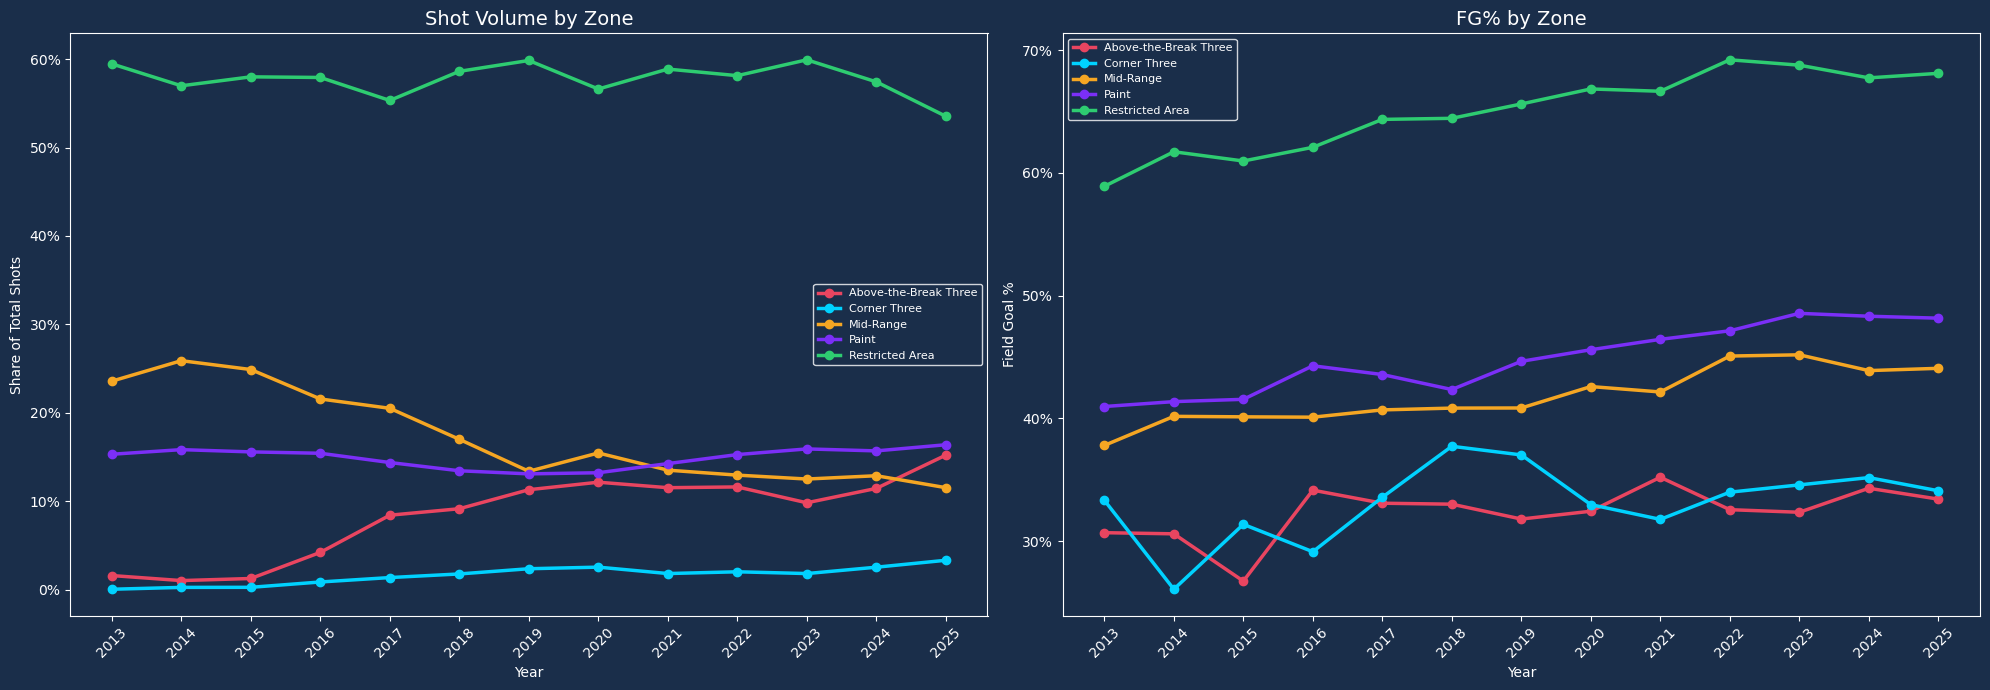

In [7]:
volume = center_loc_df.groupby(['YEAR', 'SHOT_ZONE']).size().unstack(fill_value=0)
volume = volume.div(volume.sum(axis=1), axis=0)
zones = efficiency_table.columns
colors = ['#e94560', '#00d2ff', '#f5a623', '#7b2ff7', '#2ecc71']
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.patch.set_facecolor('#1a2e4a')

# Left: volume
ax = axes[0]
ax.set_facecolor('#1a2e4a')
for zone, color in zip(zones, colors):
    ax.plot(volume.index, volume[zone], color=color, linewidth=2.5, marker='o', markersize=6, label=zone)
ax.set_title("Shot Volume by Zone", fontsize=14, color='white')
ax.set_ylabel("Share of Total Shots", color='white')
ax.set_xlabel("Year", color='white')
ax.tick_params(colors='white')
ax.spines[:].set_color('white')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_xticks(volume.index)
ax.set_xticklabels(volume.index, rotation=45)
ax.legend(facecolor='#1a2e4a', edgecolor='white', labelcolor='white', fontsize=8)

# Right: efficiency
ax = axes[1]
ax.set_facecolor('#1a2e4a')
for zone, color in zip(zones, colors):
    ax.plot(efficiency_table.index, efficiency_table[zone], color=color, linewidth=2.5, marker='o', markersize=6, label=zone)
ax.set_title("FG% by Zone", fontsize=14, color='white')
ax.set_ylabel("Field Goal %", color='white')
ax.set_xlabel("Year", color='white')
ax.tick_params(colors='white')
ax.spines[:].set_color('white')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_xticks(efficiency_table.index)
ax.set_xticklabels(efficiency_table.index, rotation=45)
ax.legend(facecolor='#1a2e4a', edgecolor='white', labelcolor='white', fontsize=8)

plt.tight_layout()
plt.savefig('FGVolume.png')
plt.show()

We will now create a table for each zone by year.

In [8]:
# Assign point value by zone
def point_value(row):
    if row['SHOT_ZONE'] in ['Corner Three', 'Above-the-Break Three']:
        return 3
    else:
        return 2

center_loc_df['POINTS'] = center_loc_df.apply(point_value, axis=1)
center_loc_df['MADE'] = (center_loc_df['EVENT_TYPE'] == 'Made Shot').astype(int)

# Expected value = FG% * point value
ev = center_loc_df.groupby(['YEAR', 'SHOT_ZONE']).agg(
    FGA=('MADE', 'count'),
    FGM=('MADE', 'sum'),
    PTS_VALUE=('POINTS', 'first')
).reset_index()

ev['FG_PCT'] = ev['FGM'] / ev['FGA']
ev['EV_PER_SHOT'] = ev['FG_PCT'] * ev['PTS_VALUE']

ev_table = ev.pivot(index='YEAR', columns='SHOT_ZONE', values='EV_PER_SHOT')
print(ev_table)

SHOT_ZONE  Above-the-Break Three  Corner Three  Mid-Range     Paint  \
YEAR                                                                  
2013                    0.920792      1.000000   0.756032  0.819401   
2014                    0.918033      0.782609   0.803382  0.827366   
2015                    0.802469      0.941176   0.802590  0.831108   
2016                    1.024735      0.874286   0.802026  0.885742   
2017                    0.992806      1.007380   0.813885  0.871489   
2018                    0.990465      1.131902   0.816811  0.847059   
2019                    0.954160      1.110811   0.817009  0.893014   
2020                    0.973244      0.989362   0.851884  0.911885   
2021                    1.056221      0.953353   0.843099  0.928811   
2022                    0.977025      1.019802   0.901597  0.942770   
2023                    0.970711      1.037594   0.903614  0.971158   
2024                    1.029396      1.055422   0.877910  0.966459   
2025  

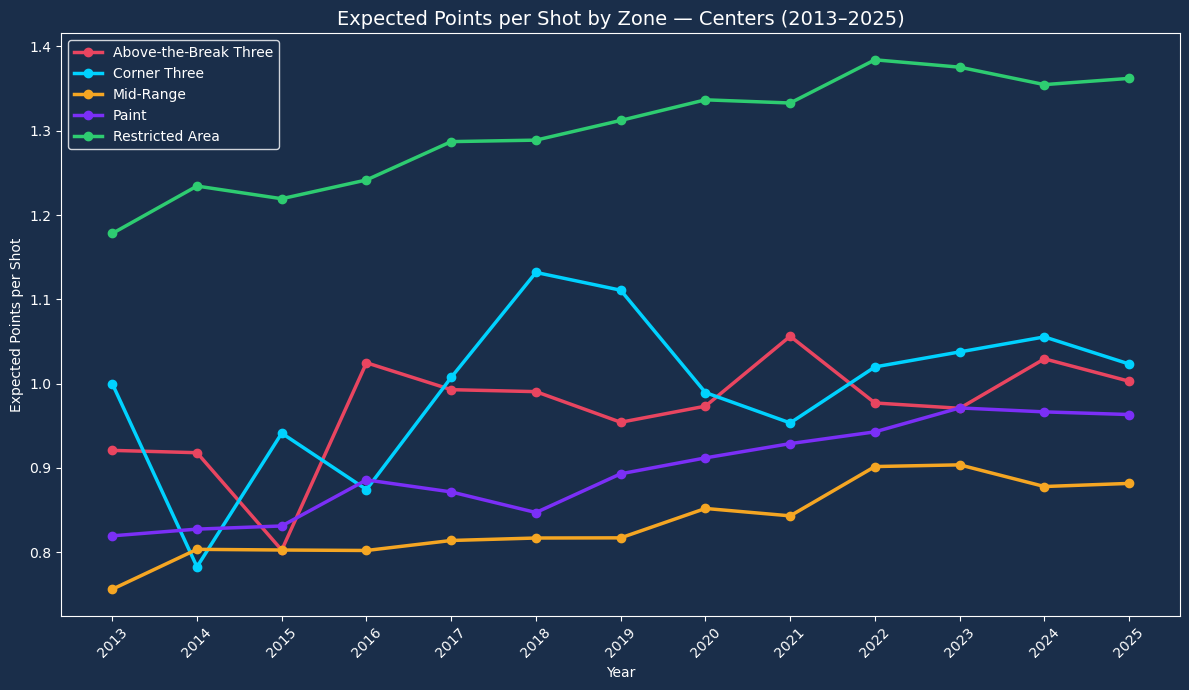

In [9]:
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#1a2e4a')
ax.set_facecolor('#1a2e4a')

zones = ev_table.columns
colors = ['#e94560', '#00d2ff', '#f5a623', '#7b2ff7', '#2ecc71']

for zone, color in zip(zones, colors):
    ax.plot(ev_table.index, ev_table[zone],
            color=color, linewidth=2.5, marker='o', markersize=6, label=zone)

ax.set_title("Expected Points per Shot by Zone — Centers (2013–2025)", fontsize=14, color='white')
ax.set_xlabel("Year", color='white')
ax.set_ylabel("Expected Points per Shot", color='white')
ax.tick_params(colors='white')
ax.spines[:].set_color('white')
ax.set_xticks(ev_table.index)
ax.set_xticklabels(ev_table.index, rotation=45)
ax.legend(facecolor='#1a2e4a', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.savefig('ExpectedPointsByZone.png')
plt.show()